## Load notebook

### Python modules

In [1]:
# standard libs
import numpy as np
import pandas as pd
from scipy import sparse
import lmfit as lm
from tqdm import tqdm
import io, sys, importlib
from contextlib import redirect_stdout

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
plt.rcParams['font.size'], plt.rcParams['axes.labelsize'] = 14, 18

# XPCS library
sys.path.append('./XPCSlibrary/')

import ID10tools as ID10
from ID10tools import Nx, Ny, Npx
importlib.reload(ID10)
ID10.set_version('v2')

import XPCStools as XPCS
from XPCStools import E2lambda, lambda2E, theta2Q, Q2theta, decorrelation_f
importlib.reload(XPCS)
XPCS.set_beamline('ID10')

import COSMICRAYtools as COSMIC
importlib.reload(COSMIC)
COSMIC.set_beamline('ID10')

#### EXPERIMENTAL VARIABLES ####
XPCS.set_expvar(1350, 1350, 7.1)
ID10.Nfmax_dense_file = 2000
ID10.Nfmax_sparse_file = 5000
################################

###### FOLDER PATHS ######
from folder_paths import *
##########################

### Functions

In [2]:
def plotfit_4damaged_vGeO2(itime, g2, t1_fit, t2_fit, save=True):

    print("Using Global variables: model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan")    

    if t1_fit is None: t1_fit = 0
    if t2_fit is None: t2_fit = 1e100
    
    g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])

    # DATA PLOTS
    plt.figure(figsize=(10,5))
    plt.scatter(g2[0], g2[1], s=1, c='C0')
    t_mt, g2_mt, dg2_mt = XPCS.get_g2mt_fromling2(itime, g2[1], g2[2])
    plt.errorbar(t_mt, g2_mt, yerr=dg2_mt, fmt = 'o', c='C1')

    tmask = (t1_fit<g2[0])*(g2[0]<t2_fit)
    x, y, dy =  g2[0][tmask], g2[1][tmask], g2[2][tmask]

    # FIT
    fit = model.fit(y, params, t=x, method='least_squares', weights=1/dy)
    g2fit.loc[0] = [Q_notebook, dQ_notebook,
                    fit.params['tau'].value, fit.params['tau'].stderr, fit.params['tau'].stderr/fit.params['tau'].value*100,
                    fit.params['beta'].value, fit.params['beta'].stderr, fit.params['beta'].stderr/fit.params['beta'].value*100,
                    fit.params['c'].value, fit.params['c'].stderr, fit.params['c'].stderr/fit.params['c'].value*100,
                    fit.params['y0'].value, fit.params['y0'].stderr, fit.params['y0'].stderr/fit.params['y0'].value*100,
                    fit.redchi,]
    if save: g2fit.to_csv(f"{g2fit4damaged_vGeO2_folder}g2fit-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}-Q={Q_notebook}-dQ={dQ_notebook}.txt", index=False)
    display(g2fit)

    # PLOT FIT
    x = np.arange(np.min(g2[0]), np.max(g2[0]), 1e-2)
    y = fit.eval(t=x)
    plt.plot(x, y, c='black', linestyle='--')
    if t1_fit!=0:     plt.axvline(t1_fit, color='red', linestyle='--')
    if t2_fit!=1e100: plt.axvline(t2_fit, color='red', linestyle='--')

    plt.xlabel('t [s]')
    plt.ylabel('g2')
    plt.xscale('log')


def plotfit_bydose(itime, Lbin, g2, t1_fit, t2_fit):

    print("Using Global variables: Nbunch, model, params, Q_notebook, dQ_notebook, sample_name, Ndataset, Nscan")   
    
    if t1_fit is None: t1_fit = 0
    if t2_fit is None: t2_fit = 1e100
    if Lbin is None: Lbin=1

    g2fit = pd.DataFrame(columns=['Q', 'dQ', 'tau', 'dtau', 'dtau%', 'beta', 'dbeta', 'dbeta%', 'c', 'dc', 'dc%', 'y0', 'dy0', 'dy%', 'redchi2'])
    g2fit.index.name = 'tw'

    plt.figure(figsize=(10,5))
    for i,k in enumerate(g2.keys()):
        t_mt, g2_mt, dg2_mt = XPCS.get_g2mt_fromling2(itime*Lbin, g2[k][1], g2[k][2])
        plt.scatter(g2[k][0], g2[k][1], s=1, c='C'+str(i))
        plt.errorbar(t_mt, g2_mt, yerr=dg2_mt, fmt = 'o', c='C'+str(i), label =f'd = {k}s')
        
        tmask = (t1_fit<g2[k][0])*(g2[k][0]<t2_fit)
        x, y, dy =  g2[k][0][tmask], g2[k][1][tmask], g2[k][2][tmask]
        
        fit = model.fit(y, params, t=x, method='least_squares', weights=1/dy)
        g2fit.loc[k] = [Q_notebook, dQ_notebook,
                        fit.params['tau'].value, fit.params['tau'].stderr, fit.params['tau'].stderr/fit.params['tau'].value*100,
                        fit.params['beta'].value, fit.params['beta'].stderr, fit.params['beta'].stderr/fit.params['beta'].value*100,
                        fit.params['c'].value, fit.params['c'].stderr, fit.params['c'].stderr/fit.params['c'].value*100,
                        fit.params['y0'].value, fit.params['y0'].stderr, fit.params['y0'].stderr/fit.params['y0'].value*100,
                        fit.redchi,]

        x = np.arange(np.min(g2[k][0]), np.max(g2[k][0]), 1e-2)
        y = fit.eval(t=x)
        plt.plot(x, y,)

    if t1_fit!=0:     plt.axvline(t1_fit, color='red', linestyle='--')
    if t2_fit!=1e100: plt.axvline(t2_fit, color='red', linestyle='--')

    plt.xlabel('t [s]')
    plt.ylabel('g2')
    plt.xscale('log')
    plt.ylim(1, 1.04)
    plt.legend()
    plt.tight_layout(); plt.show()

    display(g2fit)

    if Nbunch != 1:
        plt.figure(figsize=(10,5))
        plt.title('tau')
        plt.errorbar(g2fit.index, g2fit.tau,  yerr=g2fit.dtau, fmt='o')
        plt.xlabel('t [s]')
        plt.ylabel('tau [s]')
        plt.xlim(0)
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(10,5))
        plt.title('beta')
        plt.errorbar(g2fit.index, g2fit.beta,  yerr=g2fit.dbeta, fmt='o')
        plt.xlabel('t [s]')
        plt.ylabel('beta')
        plt.xlim(0)
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(10,5))
        plt.title('c')
        plt.errorbar(g2fit.index, g2fit.c,  yerr=g2fit.dc, fmt='o')
        plt.xlabel('t [s]')
        plt.ylabel('c')
        plt.xlim(0)
        plt.tight_layout(); plt.show()

        plt.figure(figsize=(10,5))
        plt.title('y0')
        plt.errorbar(g2fit.index, g2fit.y0,  yerr=g2fit.dy0, fmt='o')
        plt.xlabel('t [s]')
        plt.ylabel('y0')
        plt.tight_layout(); plt.show()

## Load e4m masks

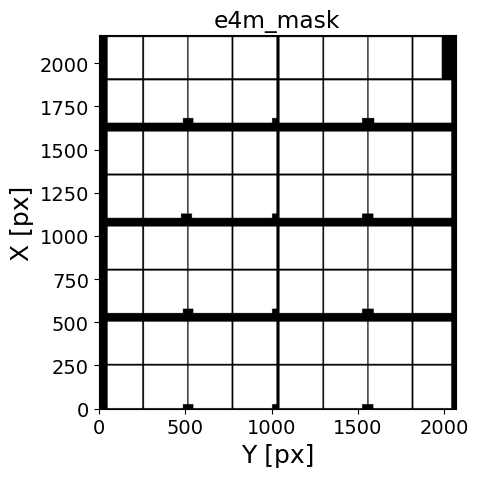

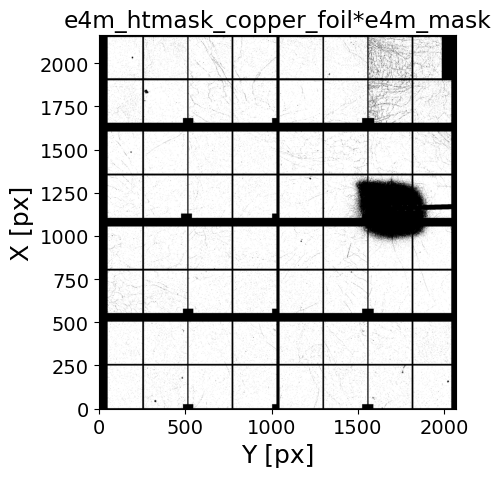

In [3]:
### e4m MASKS
e4m_htmask_copper_foil = np.load(MASKS_folder+'e4m_htmask_copper_foil_30um_1_1'+'.npy')
e4m_mask = np.load(MASKS_folder+'e4m_mask'+'.npy')

plt.figure(figsize=(5, 5))
plt.imshow((e4m_mask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.title('e4m_mask')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 5))
plt.imshow((e4m_htmask_copper_foil*e4m_mask).reshape(Nx,Ny), cmap='gray', origin='lower')
plt.xlabel('Y [px]')
plt.ylabel('X [px]')
plt.title('e4m_htmask_copper_foil*e4m_mask')
plt.tight_layout()

## Choose XPCS scan 4 analyisis

In [4]:
#######################################
sample_name = 'GeO2_7_170C'
Ndataset = 1
Nscan = 3
#######################################

## Beamstop mask

In [5]:
#######################################
Nfi, Nff = 0, 1000
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=1, )

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/1 loops)
Done! (elapsed time = 0.07 s)
Concatenating vectors ...
Done! (elapsed time = 0.01 s)
	 | Sparse array loaded from ../RAW_DATA/GeO2_7_170C/GeO2_7_170C_0001/scan0003/
	 | Shape:       (1000, 4471016)
	 | Sparsity:     2.2e-04
	 | Memory usage (scipy.csr_array): 0.011 GB (np.array usage: 16.656 GB)


################################################################################
Maximum count in the whole run -> 242.0
# of pixels above Ith_high treshold ->  864277 pixels (of 4471016 => 19.33 %)
################################################################################



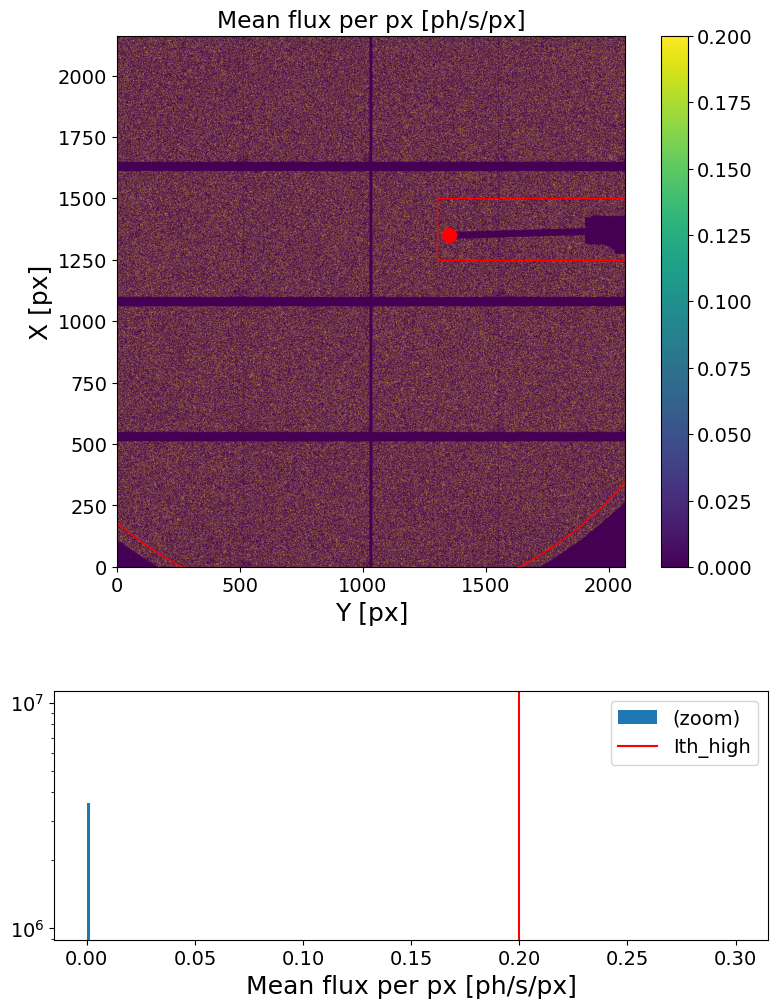

In [6]:
geom = [{'geom':'Rectangle', 'x0':1250, 'y0':1300, 'xl':250, 'yl':1950, 'inside':False},
        {'geom':'Circle', 'Cx':1300, 'Cy':950, 'r':1470, 'inside':True}, 
        ]
XPCS.gen_plots4mask(e4m_data, itime, Ith_high=.2, mask_geom=geom,)

#################################################
Masked area =  93.74594052000708 %
#################################################



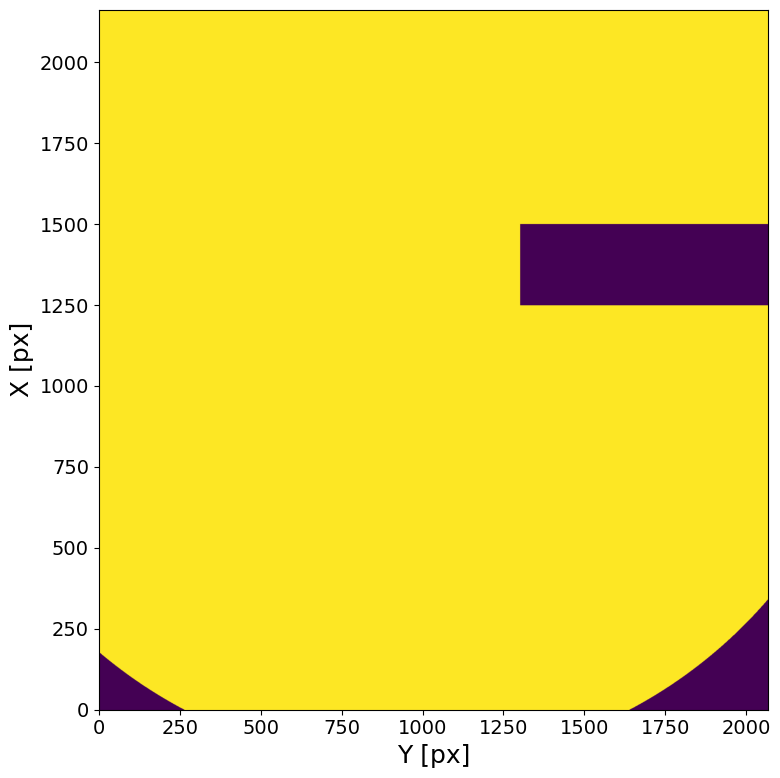

In [7]:
bs_mask = XPCS.gen_mask(mask_geom=geom)

## Q mask 4 testing!

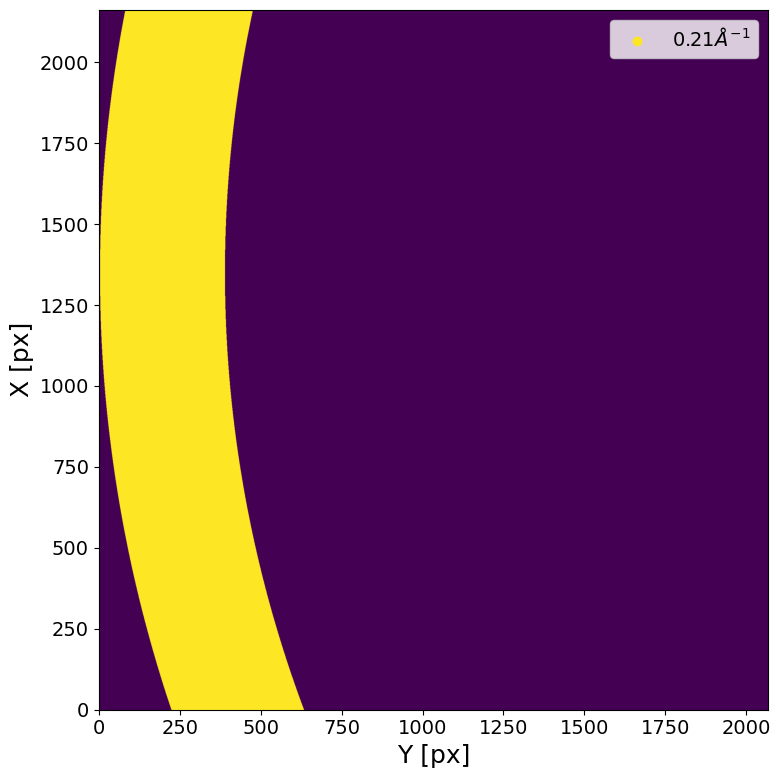

In [8]:
###################
Q_notebook = .21 # [.21, .19, .17, .15, .13]
dQ_notebook = .01 # => Q_width = 2*dQ
###################

Qmask = XPCS.gen_Qmask(Ei, theta, Q_notebook, dQ_notebook, Qmap_plot=False)

## XPCS scan X-Y analysis

### Load full scan

In [9]:
#######################################
Nfi, Nff = 1000, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=50)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1800288
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 33.01 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00013.h5 (14/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00028.h5 (29/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00037.h5 (38/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00004.h5 (5/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00012.h5 (13/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00014.h5 (15/361 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_0003

### Intensity analysis

In [10]:
####################
Lbin = 10
Nstep = 100
mask = None #e4m_mask*e4m_htmask*bs_mask*Qmask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))

<SecondaryAxis: >

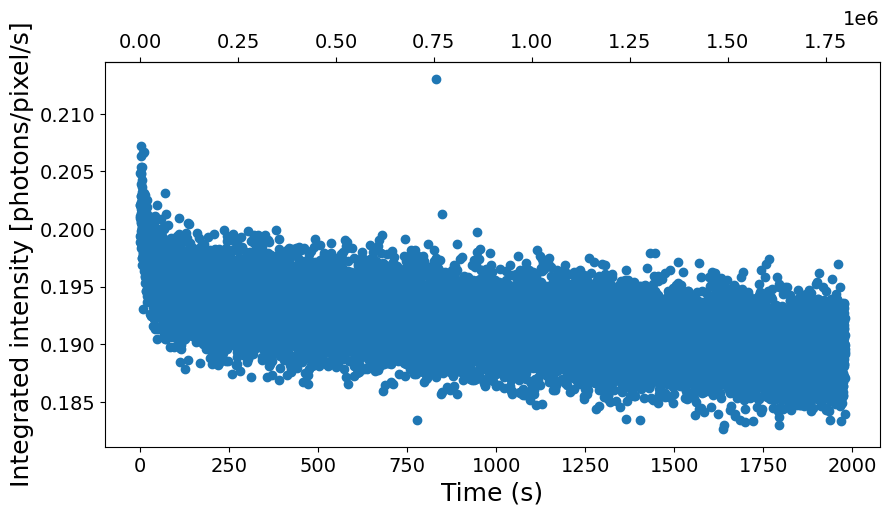

In [11]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Flux profile with mask=e4m_mask*bs_mask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  414855 pixels (of 4471016 => 11.96 %)
# of pixels below Ith_low treshold ->  419539 pixels (of 4471016 => 12.09 %)
################################################################################



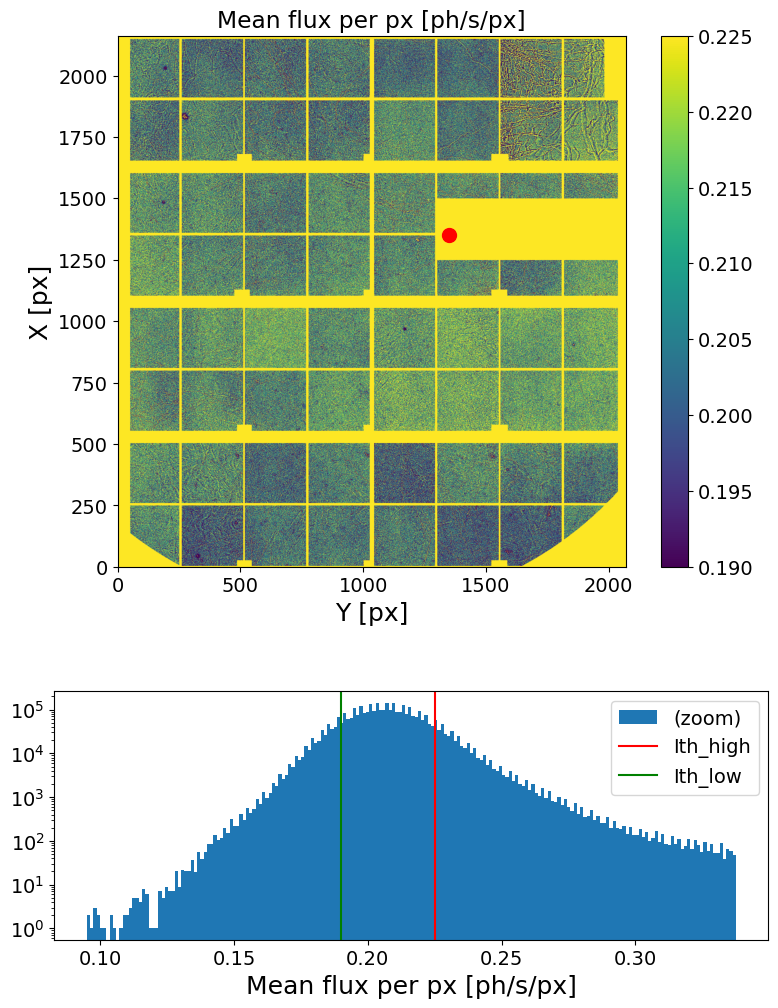

In [12]:
##################
Ith_low=.19
Ith_high=.225
##################
 
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=Ith_low, Ith_high=Ith_high, Nfi=0, Nff=None, mask=e4m_mask*bs_mask)

### Flux profile with mask = e4m_mask * bs_mask * e4m_htmask_copper_foil

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  373257 pixels (of 4471016 => 11.22 %)
# of pixels below Ith_low treshold ->  385080 pixels (of 4471016 => 11.58 %)
################################################################################



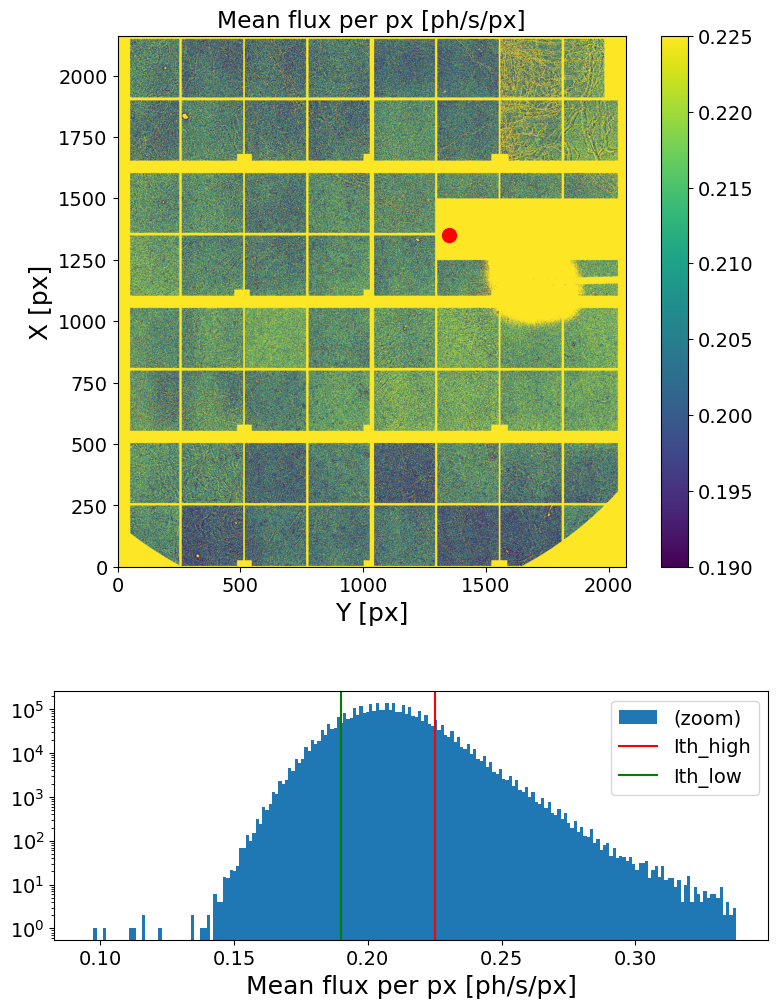

In [13]:
##################
Ith_low=.19
Ith_high=.225
##################
 
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=Ith_low, Ith_high=Ith_high, Nfi=0, Nff=None, mask=e4m_mask*bs_mask*e4m_htmask_copper_foil)

### Mask generation

#################################################
Masked area =  58.93662648489739 %
#################################################



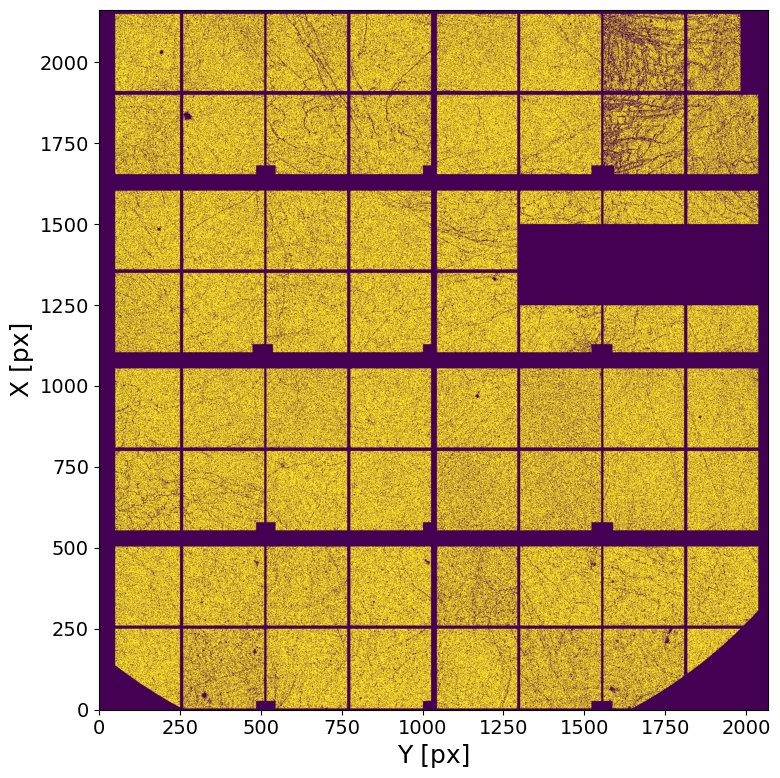

In [ ]:
##################
Ith_low=.19
Ith_high=.225
##################

e4m_htmask = XPCS.gen_mask(e4m_data=e4m_data, itime=itime, mask=e4m_mask*bs_mask, Ith_high=Ith_high, Ith_low=Ith_low, Nfi=None, Nff=None, hist_plots=False)
np.save(MASKS_folder  + f'e4m_htmask-{sample_name}_{str(Ndataset).zfill(4)}_{str(Nscan).zfill(4)}.npy', e4m_htmask)

## Test

### Load full test scan

In [15]:
#######################################
sample_name = 'GeO2_3_240C'
Ndataset = 1
Nscan = 4
Nfi, Nff = 1000, None
#######################################

scan = ID10.load_scan(RAW_folder, sample_name, Ndataset, Nscan)
Ei = scan['monoe']
itime = scan['fast_timer_period'][0]
theta = scan['delcoup']
Q = round(XPCS.theta2Q(Ei,  theta),2)

print('#############################')
print('command =', scan['command'])
print('Ei =', Ei)
print('itime =', itime)
print('theta =', theta)
print('Q =', Q)
print('T = {:.2f} min'.format(len(scan['fast_timer_period'])*itime/60))   
print('#############################\n')

e4m_data = ID10.load_sparse_e4m(RAW_folder, sample_name, Ndataset, Nscan, Nfi, Nff,  n_jobs=50)
e4m_data = COSMIC.fast_gamma_filter(e4m_data, Imaxth_high=4)

#############################
command = mtimescan 0.001 1 1500240
Ei = 9.699998837562536
itime = 0.0011
theta = 1.7500000000000004
Q = 0.15
T = 27.50 min
#############################

Loading sparse array ...
	 -> loading file eiger4m_v2_sparse_frame_0_00000.h5 (1/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00044.h5 (45/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00010.h5 (11/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00003.h5 (4/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00005.h5 (6/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00016.h5 (17/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00006.h5 (7/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00002.h5 (3/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00001.h5 (2/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00007.h5 (8/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00008.h5 (9/301 loops)
	 -> loading file eiger4m_v2_sparse_frame_0_00018.

### Intensity analysis

In [16]:
####################
Lbin = 10
Nstep = 100
mask = e4m_mask*e4m_htmask*bs_mask
####################

It = np.vstack(XPCS.get_It(e4m_data, itime, mask=mask, Lbin=Lbin, Nstep=Nstep))

<SecondaryAxis: >

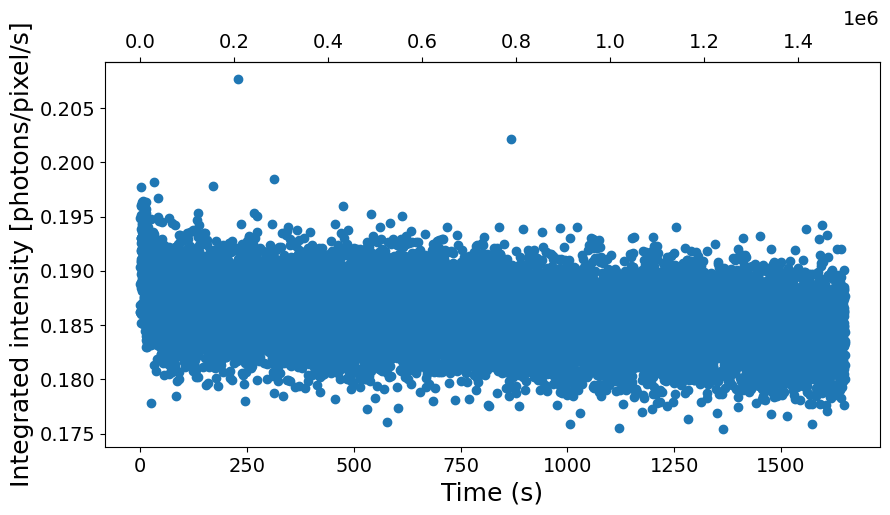

In [17]:
plt.figure(figsize=(10,5))
plt.scatter(It[0], It[1], label='It')
plt.xlabel('Time (s)')
plt.ylabel('Integrated intensity [photons/pixel/s]')
plt.gca().secondary_xaxis('top', functions=(lambda x: x/itime, lambda x: x*itime))
#plt.xlim(0, 3000)

### Flux profile with mask=e4m_mask*bs_mask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  228123 pixels (of 4471016 => 6.58 %)
# of pixels below Ith_low treshold ->  470067 pixels (of 4471016 => 13.55 %)
################################################################################



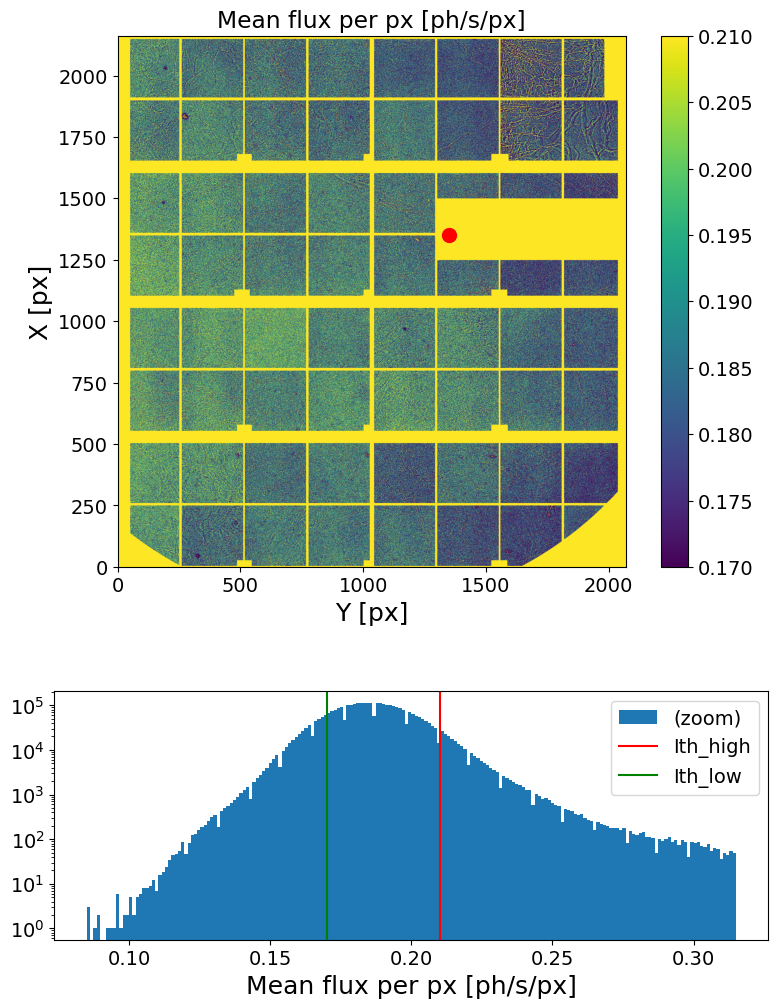

In [18]:
##################
Ith_low=.17
Ith_high=.21
##################
 
XPCS.gen_plots4mask(e4m_data, itime, Ith_low=Ith_low, Ith_high=Ith_high, Nfi=None, Nff=None, mask=e4m_mask*bs_mask)

### Flux profile with mask = e4m_mask * bs_mask * e4m_htmask_copper_foil

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  198006 pixels (of 4471016 => 5.95 %)
# of pixels below Ith_low treshold ->  425590 pixels (of 4471016 => 12.8 %)
################################################################################



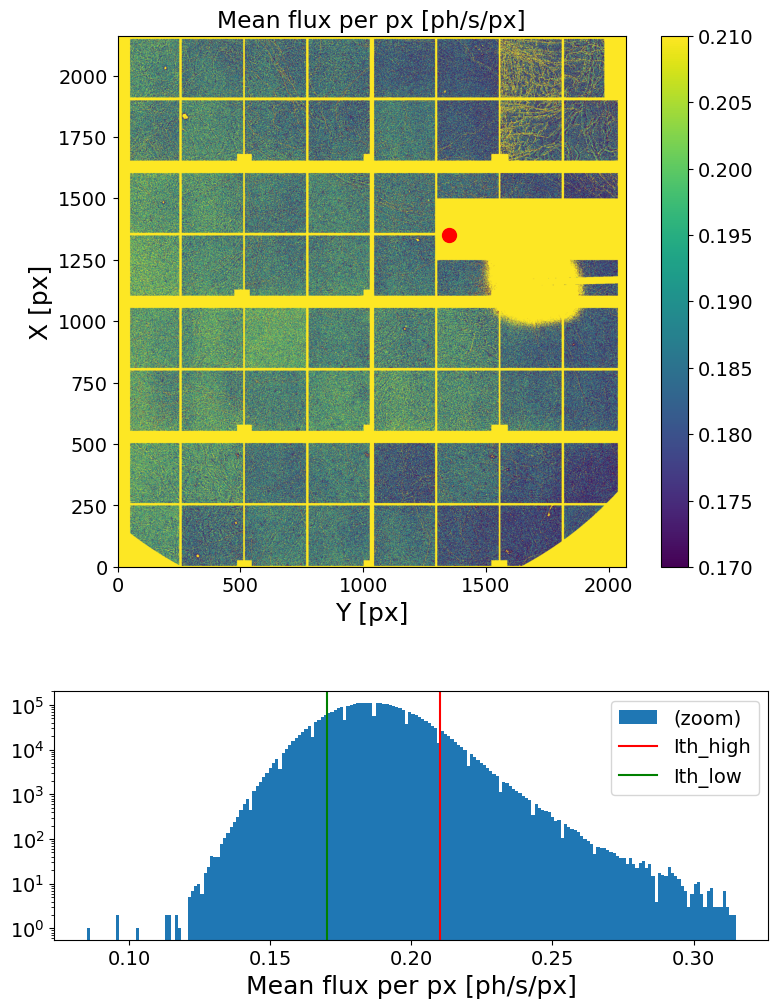

In [19]:
##################
Ith_low=.17
Ith_high=.21
##################

XPCS.gen_plots4mask(e4m_data, itime, Ith_low=Ith_low, Ith_high=Ith_high, Nfi=None, Nff=None, mask=e4m_mask*bs_mask*e4m_htmask_copper_foil)

### Flux profile with mask = e4m_mask * bs_mask * e4m_htmask

################################################################################
Maximum count in the whole run -> 4.0
# of pixels above Ith_high treshold ->  105922 pixels (of 4471016 => 4.02 %)
# of pixels below Ith_low treshold ->  320394 pixels (of 4471016 => 12.16 %)
################################################################################



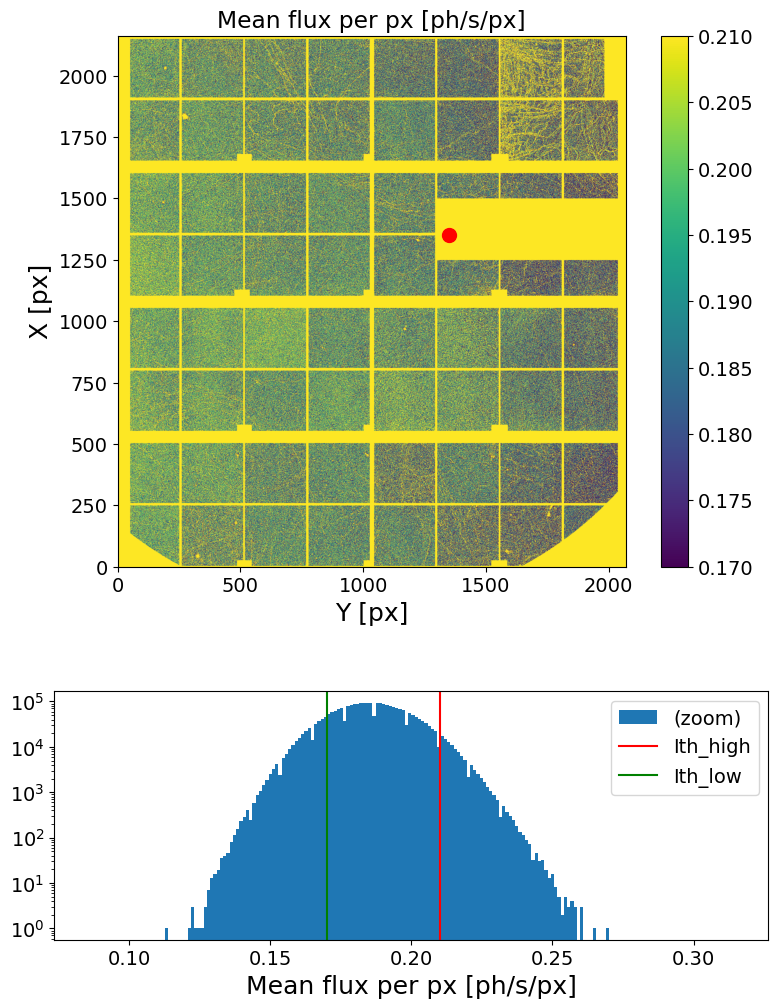

In [20]:
##################
Ith_low=.17
Ith_high=.21
##################

XPCS.gen_plots4mask(e4m_data, itime, Ith_low=Ith_low, Ith_high=Ith_high, Nfi=None, Nff=None, mask=e4m_mask*bs_mask*e4m_htmask)